# A Generalised Data-Driven Shoreline Model Trained on the South-East Australian Coastline

**Kit Calcraft<sup>1</sup>, Joshua A. Simmons<sup>2</sup>, Lucy A. Marshall<sup>3</sup>, Kristen D. Splinter<sup>1</sup>**  
<sup>1</sup>Water Research Laboratory, School of Civil and Environmental Engineering, UNSW Sydney  
<sup>2</sup>ARC Training Centre in Data Analytics for Resources and Environments (DARE), Sydney, NSW, Australia  
<sup>3</sup>Faculty of Engineering, The University of Sydney  

---

### Workflow Description
This notebook provides a complete workflow for training, loading, and evaluating a generalised shoreline forecasting model.  
- **Configuration**: Model hyperparameters and data settings are loaded from YAML files.  
- **Data Preparation**: Dataloaders are constructed to manage training and holdout sets.  
- **Model Build**: A Transformer-based architecture is instantiated and initialised.  
- **Training / Weight Loading**: The model can either be trained from scratch or initialised with pretrained weights
- **Evaluation and Visualisation**: Output at selected transect

In [1]:
try:
    import google.colab
    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    import os
    import sys

    sys.path.append('/content/drive/MyDrive/Transformer-GPU')
    os.chdir('/content/drive/MyDrive/Transformer-GPU')

    !pip install whittaker_eilers

In [2]:
# === Standard libraries ===
import warnings
import yaml

# === PyTorch ===
import torch

# === Data, models, utilities ===
from functions.load_data import FullModelData
from functions.model_object import *
from functions.plotting import *
from functions.misc import *

# === Plotting / statistics ===
import matplotlib.pyplot as plt

# --- Device setup ---
if torch.cuda.is_available():
    print(f"Connected to GPU: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    print("GPU not available. Falling back to CPU.")
    device = "cpu"

# --- Warning filters ---
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

# --- Plot style ---
plt.style.use("bmh")
plt.rcParams["font.family"] = "Times New Roman"

GPU not available. Falling back to CPU.


/Users/kitcalcraft/Documents/GitHub/A_Generalised_ShorelineModel/tft/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# === Model Configuration and Data Setup ===
settings = yaml.safe_load(open("config/model_settings.yml", "r"))
settings["holdout_sites"] = settings["training_sites"] # example of has single transect, holdout data cannot be empty, this is essentially full model deployemnt

data = FullModelData(settings)
settings

{'case': 'Regional_NSW_dataset_updated',
 'optimizer': 'Adam',
 'loss': 'MSE',
 'forcing_freq': '7D',
 'Model': 'TFT',
 'Mode': 'Eval',
 'seed': 42,
 'use_staticEnrichment': True,
 'use_sequentialProcessing': True,
 'use_multiheadAttention': True,
 'smoothing_lambda': 50,
 'gap_threshold': 10,
 'learning_rate': 3.14e-05,
 'batch_size': 512,
 'sequence_length': 260,
 'output_length': 260,
 'epochs': 100,
 'warmup': 0.4,
 'attention_heads': 4,
 'lstm_layers': 2,
 'd_model': 256,
 'init_lambda': 0,
 'variance_lambda': 0,
 'l1_lambda': 0,
 'l2_lambda': 0.001,
 'trend_lambda': 0,
 'neuron_dropout': 0.25,
 'use_prev_target': True,
 'numerical_static_inputs': ['Beach_Slope',
  'Orientation',
  'Length',
  'Relative_Transect_Position',
  'Average_Beach_Orientation'],
 'catagorical_static_inputs': None,
 'dynamic_inputs': ['Dp_mean', 'Hs_mean', 'Hs_peak', 'Tp_mean'],
 'training_sites': ['aus0047',
  'aus0049',
  'aus0050',
  'aus0052',
  'aus0053',
  'aus0054',
  'aus0055',
  'aus0057',
  'aus0

In [4]:
# === Model Initialization and Architecture Build ===
tft = Transformer25(data, settings)   # initialise model wrapper
tft.build_dataloaders()               # prepare training/validation data loaders
tft.build_model(None)                 # construct model architecture

(a) Load pretrained weights (returns a status object)

In [5]:
model = tft.model
state_dict = torch.load("model_weights.pth", map_location=device)
status = model.load_state_dict(state_dict)
print(status)
model.to(device)

<All keys matched successfully>


TFT(
  (static_encoder_enrichment): GatedResidualNetwork(
    (transform_residual): Linear(in_features=5, out_features=256, bias=True)
    (Dense1): Linear(in_features=5, out_features=256, bias=True)
    (Dense2): Linear(in_features=256, out_features=256, bias=True)
    (GLU): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): Sigmoid()
    )
    (dropout): Dropout(p=0.25, inplace=False)
    (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ELU): ELU(alpha=1.0)
  )
  (static_encoder_sequential_cell_init): GatedResidualNetwork(
    (transform_residual): Linear(in_features=5, out_features=256, bias=True)
    (Dense1): Linear(in_features=5, out_features=256, bias=True)
    (Dense2): Linear(in_features=256, out_features=256, bias=True)
    (GLU): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): Sigmoid()
    )
    (dropout): Dropout(p=0.25, inplace=False)
    (layer_norm): LayerNorm((256,), eps

(b) Or: Train from scratch

In [ ]:
tft.train_model()
model = tft.model

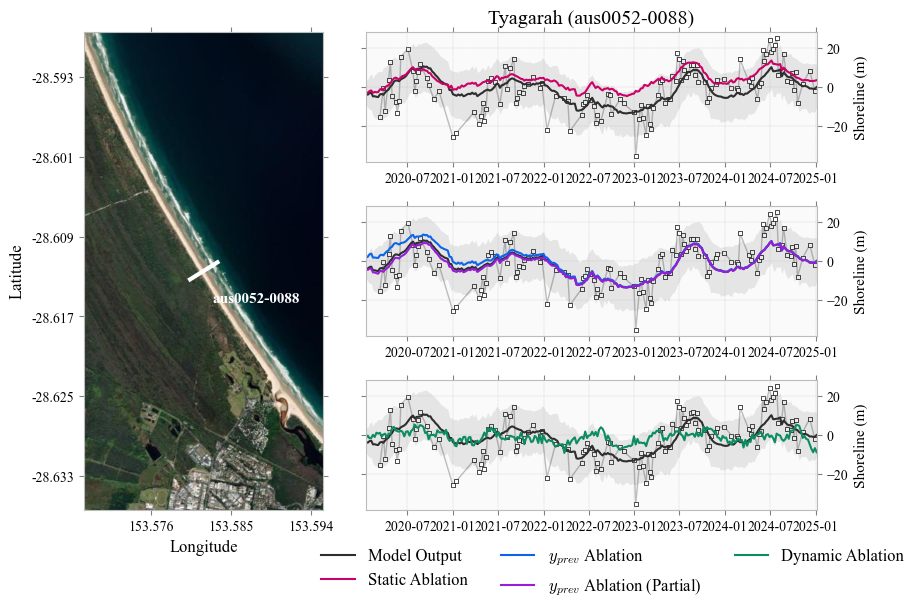

In [6]:
# === Evaluation and Visualisation ===
transect = "aus0052-0088"                 # site identifier
compare_outputs(transect, model, data, settings)  # generate figures + diagnostics